# Logistic Regression: Hypothesis and Activation Functions

> 📖 Book: [ch06 – Logistic regression](../../.claude/skills/ml-knowledge/chapters/ch06-logistic-regression.md) · Prev: [01_linear_regression/08](../01_linear_regression/08_review.ipynb) · Next: [02 Cost function](02_cost_and_gradient.ipynb)

Linear regression can output any real number, but many problems need a discrete answer:

- a patient needs a "yes" or "no" from a diagnostic test;
- the post office must recognize the character "0" among all characters in a handwritten address;
- photo databases want to identify what's in an image (a person, a building, a tree, an animal);
- mail servers try to detect and filter spam;
- banks try to predict whether a client will default on a loan.

In all these cases the answer is an element of a finite set of options. We train on examples whose class is known and use the trained model to predict the class of new data. Methods include naive Bayes, decision trees, $k$-nearest neighbors, neural networks, SVMs and **logistic regression**.

The name "logistic" comes from reducing the problem to a Boolean decision: TRUE/FALSE, yes/no, 1/0. Even multi-class problems can be reduced to this binary paradigm (see [04 One-vs-all](04_one_vs_all.ipynb)). For now $y \in \{0, 1\}$: $0$ is the **negative** class ("−"), $1$ the **positive** class ("+").

## Why not just linear regression?

As in linear regression we want $h_\theta$ with $X\theta \approx y$, minimizing $\frac12\|X\theta - y\|^2$. But:

1. $h_\theta(x) = x^T\theta$ takes values in a continuous, unbounded set;
2. it is not a probability.

To interpret $h_\theta$ as a probability we want $0 \le h_\theta \le 1$; then we can decide, e.g., "patient $q_i$ has cancer if $p(\text{cancer} \mid x^{(i)}, \theta) \ge 0.5$". We need a mapping from the whole real line to an interval such as $[0, 1]$: an **activation function**.

## Activation functions

Desired properties:

- one-to-one mapping from input to output;
- differentiable;
- monotonically increasing;
- range in $[0, 1]$ or $[-1, 1]$.

Some [examples](https://en.wikipedia.org/wiki/Sigmoid_function#Examples):

**Hyperbolic tangent** maps $\mathbb{R}$ to $(-1, 1)$ keeping $0$ fixed:

$$
\tanh x = \frac{2}{1 + e^{-2x}} - 1 = \frac{\sinh x}{\cosh x}.
$$

**Sigmoid (logistic) function** maps $\mathbb{R}$ to $(0, 1)$:

$$
S(x) = \frac{1}{1 + e^{-x}}, \qquad \lim_{x\to-\infty}S(x) = 0, \quad \lim_{x\to\infty}S(x) = 1 .
$$

It increases monotonically like a cumulative distribution. Other functions (e.g. $\arctan$) have similar properties, but the sigmoid has a remarkably convenient derivative:

$$
S'(x) = \frac{e^{-x}}{(1 + e^{-x})^2}
= \frac{1}{1 + e^{-x}}\,\frac{e^{-x}}{1 + e^{-x}}
= \frac{1}{1 + e^{-x}}\left(1 - \frac{1}{1 + e^{-x}}\right)
= S(x)\,\big(1 - S(x)\big).
$$

**ReLU (rectified linear unit)**:

$$
\mathrm{ReLU}(x) = \max\{0, x\} = \begin{cases} x & x > 0 \\ 0 & \text{otherwise.} \end{cases}
$$

ReLU is not a classic activation: it is not one-to-one, not differentiable at the origin, unbounded on $(0, \infty)$ and not strictly increasing. Still, ReLUs are very popular and work better as nonlinear units in deep (convolutional) networks. Crucially, they help overcome the **vanishing gradient problem** that used to prevent training multi-layer networks: $S'(x) \le 1/4$ and $\to 0$ for large $|x|$, while $\mathrm{ReLU}'(x) = 1$ for $x > 0$.

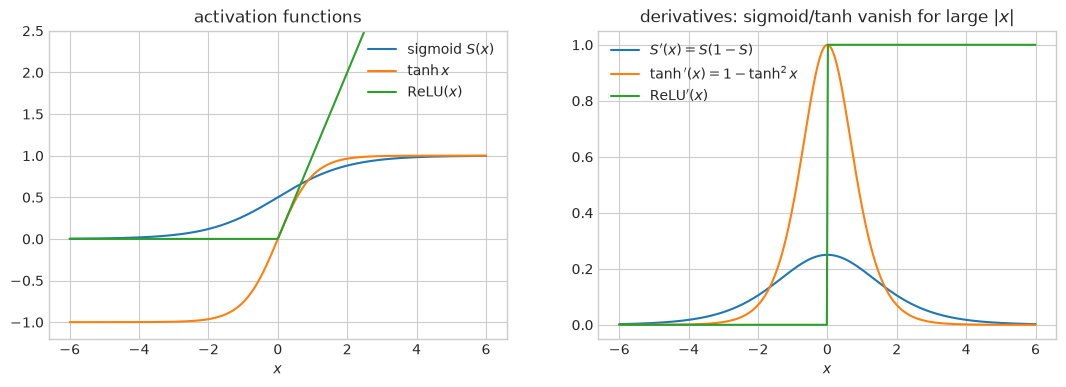

max |S' numeric - S(1-S)| = 1.3204715099135456e-10


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from ml.logistic import relu, sigmoid, tanh

plt.style.use("seaborn-v0_8-whitegrid")

x = np.linspace(-6, 6, 400)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for f, name in [(sigmoid, r"sigmoid $S(x)$"), (tanh, r"$\tanh x$"), (relu, r"ReLU$(x)$")]:
    ax[0].plot(x, f(x), label=name)
ax[0].set(ylim=(-1.2, 2.5), xlabel="$x$", title="activation functions")
ax[0].legend()

ax[1].plot(x, sigmoid(x) * (1 - sigmoid(x)), label=r"$S'(x) = S(1-S)$")
ax[1].plot(x, 1 - tanh(x) ** 2, label=r"$\tanh'(x) = 1 - \tanh^2 x$")
ax[1].plot(x, (x > 0).astype(float), label=r"ReLU$'(x)$")
ax[1].set(xlabel="$x$", title="derivatives: sigmoid/tanh vanish for large $|x|$")
ax[1].legend()
plt.show()

# numerical check of S' = S(1 - S)
h = 1e-6
print("max |S' numeric - S(1-S)| =", np.max(np.abs((sigmoid(x + h) - sigmoid(x - h)) / (2 * h) - sigmoid(x) * (1 - sigmoid(x)))))

## Prediction with logistic regression

Let the labels be $y^{(i)} \in \{0, 1\}$. $X\theta$ has components $-\infty < x^{(i)}\theta < \infty$, which we squeeze into $(0, 1)$ with the sigmoid:

$$
h_\theta(x^{(i)}) = S(x^{(i)}\theta) = \frac{1}{1 + e^{-x^{(i)}\theta}} .
$$

We interpret it as the probability that $y^{(i)} = 1$ given $x^{(i)}$, parametrized by $\theta$:

$$
h_\theta(x^{(i)}) = p\left(y^{(i)} = 1 \mid x^{(i)}, \theta\right), \qquad
p\left(y^{(i)} = 0 \mid x^{(i)}, \theta\right) = 1 - h_\theta(x^{(i)}) .
$$

E.g. $h_\theta(x) = 0.7$ means a 70 % chance that $y = 1$ (and 30 % that $y = 0$).

$h_\theta$ is still a continuous probability, while the labels are 0 or 1. We turn it into a class with a **threshold** $\gamma$ (usually $0.5$):

$$
h_{bin}(\theta, x^{(i)}) = \begin{cases} 1 & \text{if } S(x^{(i)}\theta) \ge \gamma \\ 0 & \text{otherwise.} \end{cases}
$$

Then we can compare the predictions with the known $y^{(i)}$ and evaluate the model (→ [03_classification_metrics](../03_classification_metrics/01_confusion_matrix_precision_recall_f1.ipynb)).

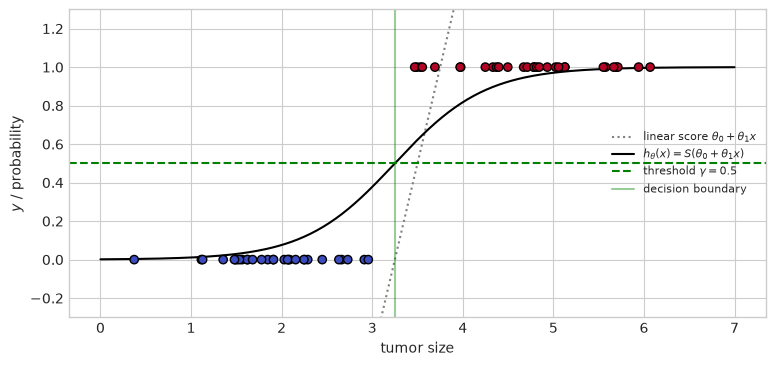

In [2]:
# One feature: tumor size -> malignant?
rng = np.random.default_rng(0)
size = np.r_[rng.normal(2, 0.7, 30), rng.normal(4.5, 0.8, 30)]
y = np.r_[np.zeros(30), np.ones(30)]
theta = np.array([-6.5, 2.0])  # hand-picked for now; fitted in the next notebook

s = np.linspace(0, 7, 300)
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(size, y, c=y, cmap="coolwarm", edgecolors="k", zorder=3)
ax.plot(s, -6.5 + 2 * s, "gray", ls=":", label=r"linear score $\theta_0 + \theta_1 x$")
ax.plot(s, sigmoid(-6.5 + 2 * s), "k", label=r"$h_\theta(x) = S(\theta_0 + \theta_1 x)$")
ax.axhline(0.5, c="g", ls="--", label=r"threshold $\gamma = 0.5$")
ax.axvline(6.5 / 2, c="g", ls="-", alpha=0.4, label="decision boundary")
ax.set(ylim=(-0.3, 1.3), xlabel="tumor size", ylabel="$y$ / probability")
ax.legend(loc="center right", fontsize=8)
plt.show()